# 04 · Sellmeier dispersion, interactively

Companion to `run.py` / `README.md`. Every slider re-evaluates the **same sympy-lambdified** `sellmeier.Material` that
`run.py` uses, so nothing here is a separate approximation.

Four experiments:
1. **Tangent–intercept**: slide a tangent along n(λ) and read n_g = n − λ dn/dλ off the λ = 0 axis (notes §11).
2. **Move the IR resonance**: change λ_ir and B_ir of silica's third Sellmeier term and watch the zero-dispersion wavelength move (notes §10).
3. **Ring FSR**: FSR = c/(n_g L) with n_g and L sliders, and the eight 200 GHz channels drawn inside one FSR (capstone).
4. **pm ↔ GHz converter** with the small-change rule Δf = −(c/λ²) Δλ.

Static outputs (default slider values) are saved in the notebook; drag the sliders in JupyterLab to explore.
The slider cells are tagged `widgets`: `run.py` executes them headless too, and only falls back to skipping them
(`out/results.json` → `notebook_status`) if the kernel's widget messaging stalls twice in a row.

In [1]:
import sys, pathlib, json
HERE = pathlib.Path.cwd().resolve()
ROOT = HERE.parents[1]                       # experiments/04_sellmeier_dispersion -> repo root
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(HERE))
from common import REF, use_style, SERIES, PALETTE, C0
import numpy as np, sympy as sp, scipy.optimize
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import sellmeier as sm
%matplotlib inline
use_style(dpi=100)
silica, silicon = sm.silica(), sm.silicon()
MATS = {"silica (Malitson)": silica, "silicon (Salzberg-Villa)": silicon}
print("n_silica(1310) =", float(silica.n(1.31)), "   n_g =", float(silica.ng(1.31)))
print("n_silicon(1310) =", float(silicon.n(1.31)), "  n_g =", float(silicon.ng(1.31)))

n_silica(1310) = 1.4468043175527276    n_g = 1.461639991743378
n_silicon(1310) = 3.5005287119841753   n_g = 3.6772225164554446


## 0. The symbolic derivation (sympy renders with MathJax in the browser; no LaTeX needed)

Start from k(ω) = n(λ(ω))·ω/c with λ = 2πc/ω and let sympy do the chain rule.

In [2]:
lam, c = sm.lam, sm.c_sym
omega = sp.symbols("omega", positive=True)
n = sp.Function("n")
k = n(2*sp.pi*c/omega) * omega / c
ng = sp.simplify((c*sp.diff(k, omega)).subs(omega, 2*sp.pi*c/lam))
D  = sp.simplify(sp.diff(ng/c, lam))
display(sp.Eq(sp.Symbol("n_g"), ng))
display(sp.Eq(sp.Symbol("D"), D))
# and the explicit group index of a generic 3-term Sellmeier
ng_sell = sm.dispersion_expressions(sp.sqrt(sm.sellmeier_n2_generic()))[2]
display(sp.Eq(sp.Symbol("n_g^{Sellmeier}"), sp.simplify(ng_sell)))

Eq(n_g, -lambda*Derivative(n(lambda), lambda) + n(lambda))

Eq(D, -lambda*Derivative(n(lambda), (lambda, 2))/c)

Eq(n_g^{Sellmeier}, lambda*(B1*lambda**3/(C1 - lambda**2)**2 + B1*lambda/(C1 - lambda**2) + B2*lambda**3/(C2 - lambda**2)**2 + B2*lambda/(C2 - lambda**2) + B3*lambda**3/(C3 - lambda**2)**2 + B3*lambda/(C3 - lambda**2))/sqrt(-B1*lambda**2/(C1 - lambda**2) - B2*lambda**2/(C2 - lambda**2) - B3*lambda**2/(C3 - lambda**2) + 1) + sqrt(-B1*lambda**2/(C1 - lambda**2) - B2*lambda**2/(C2 - lambda**2) - B3*lambda**2/(C3 - lambda**2) + 1))

## 1. Tangent–intercept construction of n_g

n_g = n − λ·dn/dλ is exactly the value where the tangent to n(λ) at λ crosses the λ = 0 axis.
Watch the square: it is lowest where D = 0 (silica, 1273 nm). For silicon it never turns around in this window.

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


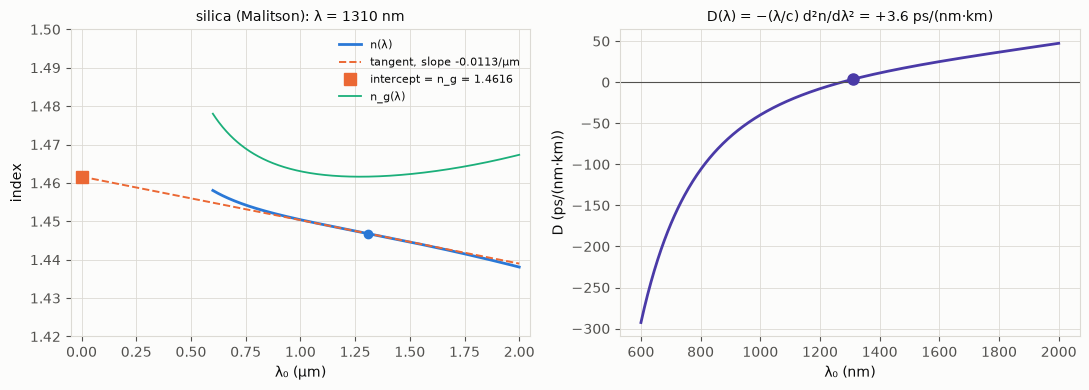

In [3]:
def tangent_plot(material="silica (Malitson)", lam_t_nm=1310):
    mat = MATS[material]
    lo, hi = (0.6, 2.0) if "silica" in material else (1.2, 2.0)
    lam_t = lam_t_nm * 1e-3
    lam_t = min(max(lam_t, lo + 0.02), hi - 0.02)
    lw = np.linspace(lo, hi, 500); xs = np.array([0.0, hi])
    nt, st = float(mat.n(lam_t)), float(mat.dn_dlam(lam_t))
    ngt, Dt = nt - st*lam_t, float(mat.D_ps_nm_km(lam_t))
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    ax = axs[0]
    ax.plot(lw, mat.n(lw), color=SERIES[0], label="n(λ)")
    ax.plot(xs, nt + st*(xs - lam_t), "--", color=SERIES[1], lw=1.4, label=f"tangent, slope {st:+.4f}/µm")
    ax.plot([lam_t], [nt], "o", color=SERIES[0]); ax.plot([0], [ngt], "s", color=SERIES[1], ms=8, label=f"intercept = n_g = {ngt:.4f}")
    ax.plot(lw, mat.ng(lw), color=SERIES[2], lw=1.3, label="n_g(λ)")
    ax.set_xlim(-0.05, hi + 0.05)
    ax.set_ylim((1.42, 1.50) if "silica" in material else (3.3, 3.9))
    ax.set_xlabel("λ₀ (µm)"); ax.set_ylabel("index"); ax.legend(fontsize=8); ax.set_title(f"{material}: λ = {lam_t*1e3:.0f} nm", fontsize=10)
    ax = axs[1]
    ax.plot(lw*1e3, mat.D_ps_nm_km(lw), color=SERIES[3]); ax.axhline(0, color=PALETTE["ink2"], lw=0.8)
    ax.plot([lam_t*1e3], [Dt], "o", color=SERIES[3], ms=8)
    ax.set_xlabel("λ₀ (nm)"); ax.set_ylabel("D (ps/(nm·km))"); ax.set_title(f"D(λ) = −(λ/c) d²n/dλ² = {Dt:+.1f} ps/(nm·km)", fontsize=10)
    plt.tight_layout(); plt.show()

tangent_plot("silica (Malitson)", 1310)

In [4]:
interact(tangent_plot, material=Dropdown(options=list(MATS), value="silica (Malitson)"),
         lam_t_nm=FloatSlider(min=650, max=1950, step=10, value=1310, description="λ (nm)"));

interactive(children=(Dropdown(description='material', options=('silica (Malitson)', 'silicon (Salzberg-Villa)…

## 2. Move the infrared resonance and watch the zero-dispersion wavelength move

Silica's third Sellmeier term is the IR pole at √C₃ = 9.896 µm with strength B₃ = 0.897. Its contribution
bends n(λ) **downward** (S_ir'' < 0); the two UV poles bend it **upward**. The ZDW is where they cancel (notes §10).
Pull the IR pole closer (smaller λ_ir) or make it stronger (bigger B_ir) and the cancellation happens at a shorter wavelength.
The UV-strength scale multiplies both UV terms' B (their curvature ∝ B_u λ_u²/λ⁴).

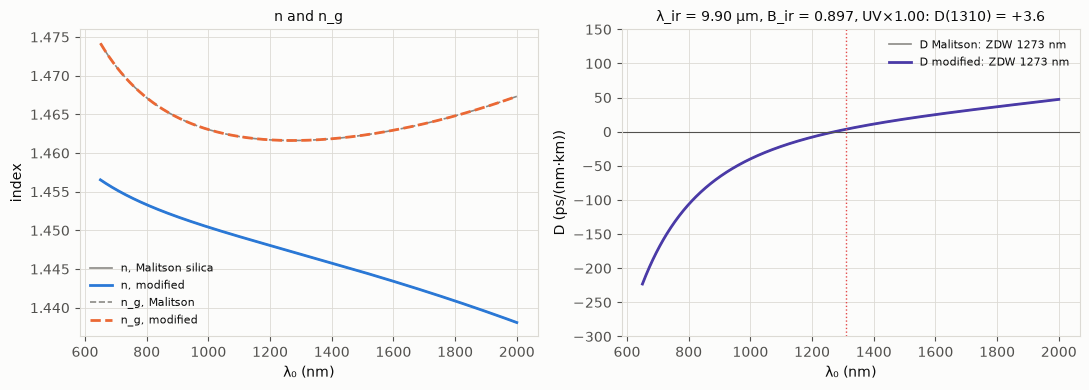

In [5]:
def custom_silica(lam_ir_um=9.896161, B_ir=0.8974794, uv_scale=1.0):
    subs = {sm.B1: sm.SILICA_B[0]*uv_scale, sm.B2: sm.SILICA_B[1]*uv_scale, sm.B3: B_ir,
            sm.C1: sm.SILICA_C[0], sm.C2: sm.SILICA_C[1], sm.C3: lam_ir_um**2}
    return sm.Material("modified silica", sp.sqrt(sm.sellmeier_n2_generic().subs(subs)), (0.3, lam_ir_um*0.5))

def zdw_of(mat, lo=0.65, hi=2.0):
    f = lambda x: float(mat.d2n_dlam2(x))
    grid = np.linspace(lo, hi, 400); v = np.array([f(x) for x in grid])
    idx = np.where(np.sign(v[:-1]) != np.sign(v[1:]))[0]
    return None if len(idx) == 0 else scipy.optimize.brentq(f, grid[idx[0]], grid[idx[0]+1])

def zdw_plot(lam_ir_um=9.896161, B_ir=0.8974794, uv_scale=1.0):
    mod = custom_silica(lam_ir_um, B_ir, uv_scale)
    lw = np.linspace(0.65, 2.0, 600)
    z0, z1 = zdw_of(silica), zdw_of(mod)
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    ax = axs[0]
    ax.plot(lw*1e3, silica.n(lw), color=PALETTE["muted"], lw=1.2, label="n, Malitson silica")
    ax.plot(lw*1e3, mod.n(lw), color=SERIES[0], label="n, modified")
    ax.plot(lw*1e3, silica.ng(lw), color=PALETTE["muted"], lw=1.2, ls="--", label="n_g, Malitson")
    ax.plot(lw*1e3, mod.ng(lw), color=SERIES[1], ls="--", label="n_g, modified")
    ax.set_xlabel("λ₀ (nm)"); ax.set_ylabel("index"); ax.legend(fontsize=8); ax.set_title("n and n_g", fontsize=10)
    ax = axs[1]
    ax.plot(lw*1e3, silica.D_ps_nm_km(lw), color=PALETTE["muted"], lw=1.2, label=f"D Malitson: ZDW {z0*1e3:.0f} nm")
    lab = f"D modified: ZDW {z1*1e3:.0f} nm" if z1 else "D modified: no zero in 0.65–2 µm"
    ax.plot(lw*1e3, mod.D_ps_nm_km(lw), color=SERIES[3], label=lab)
    ax.axhline(0, color=PALETTE["ink2"], lw=0.8); ax.axvline(1310, color=SERIES[4], ls=":", lw=1)
    ax.set_ylim(-300, 150); ax.set_xlabel("λ₀ (nm)"); ax.set_ylabel("D (ps/(nm·km))"); ax.legend(fontsize=8)
    ax.set_title(f"λ_ir = {lam_ir_um:.2f} µm, B_ir = {B_ir:.3f}, UV×{uv_scale:.2f}: D(1310) = {float(mod.D_ps_nm_km(1.31)):+.1f}", fontsize=10)
    plt.tight_layout(); plt.show()

zdw_plot()

In [6]:
interact(zdw_plot, lam_ir_um=FloatSlider(min=4.0, max=16.0, step=0.1, value=9.896161, description="λ_ir (µm)"),
         B_ir=FloatSlider(min=0.2, max=2.0, step=0.02, value=0.8974794, description="B_ir"),
         uv_scale=FloatSlider(min=0.8, max=1.2, step=0.01, value=1.0, description="UV B scale"));

interactive(children=(FloatSlider(value=9.896161, description='λ_ir (µm)', max=16.0, min=4.0), FloatSlider(val…

## 3. Ring FSR: the group index, not the effective index

FSR_f = c/(n_g L) and FSR_λ = λ²/(n_g L). The reference ring (L = 39.6 µm, n_g = 4.2) gives 1.80 THz = 10.3 nm.
The comb below draws the ring's resonances (Lorentzian, FWHM 374 pm) around 1310 nm and the eight 200 GHz WDM
channels: all eight channels (8 × 1.145 nm = 8.0 nm) must fit inside **one** FSR, which is why n_g (not n_eff = 2.5,
which would give 17.3 nm) is the number the system designer needs.

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


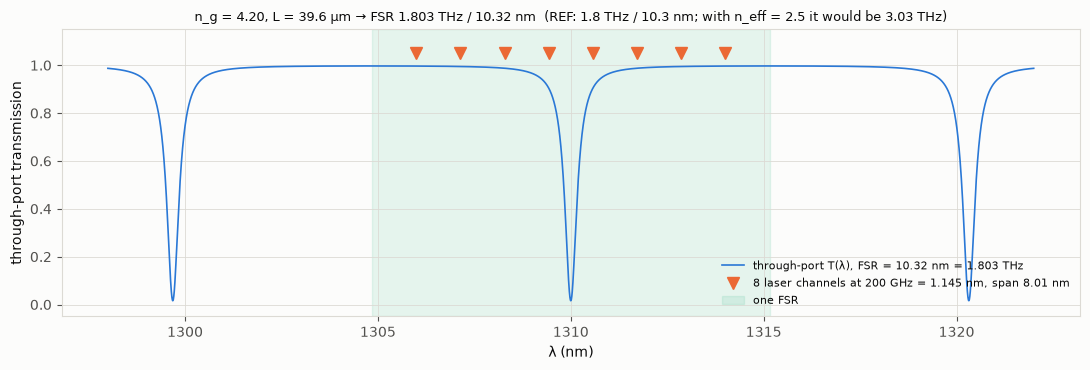

FSR = 1.8025 THz = 10.318 nm ; channels span 8.01 nm of 10.32 nm -> fits


In [7]:
def fsr_plot(ng=4.2, L_um=39.6, n_ch=8):
    lam0 = REF.lambda_nm; L = L_um*1e-6
    fsr_thz = C0/(ng*L)/1e12; fsr_nm = (lam0*1e-9)**2/(ng*L)*1e9
    ch_nm = REF.channel_spacing_ghz*1e9*(lam0*1e-9)**2/C0*1e9
    lw = np.linspace(lam0 - 12, lam0 + 12, 6000)
    m = np.arange(-4, 5); res_lines = lam0 + m*fsr_nm
    T = np.ones_like(lw)
    hw = REF.fwhm_pm*1e-3/2
    for lr in res_lines:
        T *= 1 - (1 - REF.t_min) * hw**2/((lw - lr)**2 + hw**2)
    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.plot(lw, T, color=SERIES[0], lw=1.2, label=f"through-port T(λ), FSR = {fsr_nm:.2f} nm = {fsr_thz:.3f} THz")
    chs = lam0 + (np.arange(n_ch) - (n_ch-1)/2)*ch_nm
    ax.plot(chs, np.full(n_ch, 1.05), "v", color=SERIES[1], ms=8, label=f"{n_ch} laser channels at 200 GHz = {ch_nm:.3f} nm, span {(n_ch-1)*ch_nm:.2f} nm")
    ax.axvspan(lam0 - fsr_nm/2, lam0 + fsr_nm/2, color=SERIES[2], alpha=0.1, label="one FSR")
    ax.set_ylim(-0.05, 1.15); ax.set_xlabel("λ (nm)"); ax.set_ylabel("through-port transmission")
    ax.set_title(f"n_g = {ng:.2f}, L = {L_um:.1f} µm → FSR {fsr_thz:.3f} THz / {fsr_nm:.2f} nm  (REF: 1.8 THz / 10.3 nm; with n_eff = 2.5 it would be {C0/(2.5*L)/1e12:.2f} THz)", fontsize=9.5)
    ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()
    print(f"FSR = {fsr_thz:.4f} THz = {fsr_nm:.3f} nm ; channels span {(n_ch-1)*ch_nm:.2f} nm of {fsr_nm:.2f} nm -> "
          f"{'fits' if (n_ch-1)*ch_nm < fsr_nm else 'DOES NOT FIT: a ring would see two channels'}")

fsr_plot()

In [8]:
interact(fsr_plot, ng=FloatSlider(min=2.5, max=4.8, step=0.05, value=4.2, description="n_g"),
         L_um=FloatSlider(min=25, max=60, step=0.5, value=39.6, description="L (µm)"),
         n_ch=IntSlider(min=1, max=12, value=8, description="channels"));

interactive(children=(FloatSlider(value=4.2, description='n_g', max=4.8, min=2.5, step=0.05), FloatSlider(valu…

## 4. pm ↔ GHz with the small-change rule

Δf = −(c/λ²)·Δλ. At 1310 nm, 1 nm ↔ 174.7 GHz, so 1 pm ↔ 175 MHz. The capstone numbers in frequency units: 50 pm/K ↔ 8.7 GHz/K,
FWHM 374 pm ↔ 65 GHz, δ_opt = 108 pm ↔ 19 GHz.

In [9]:
def convert(dlam_pm=50.0, lam_nm=1310.0):
    rule = C0/(lam_nm*1e-9)**2*1e-9*1e-9          # GHz per nm
    exact = (C0/(lam_nm*1e-9) - C0/((lam_nm + dlam_pm*1e-3)*1e-9))/1e9
    print(f"at λ = {lam_nm:.0f} nm: c/λ² = {rule:.2f} GHz/nm = {rule:.4g} MHz/pm")
    print(f"Δλ = {dlam_pm:.1f} pm  ->  linear rule Δf = {rule*dlam_pm*1e-3:.4f} GHz ; exact {exact:.4f} GHz ; "
          f"rule error {100*abs(exact - rule*dlam_pm*1e-3)/abs(exact):.4f} %")
    print(f"in units of the 374 pm FWHM: {dlam_pm/REF.fwhm_pm:.3f} FWHM ; in kelvin at 50 pm/K: {dlam_pm/REF.dlambda_dT_pm_per_K:.3f} K")
convert()

at λ = 1310 nm: c/λ² = 174.69 GHz/nm = 174.7 MHz/pm
Δλ = 50.0 pm  ->  linear rule Δf = 8.7347 GHz ; exact 8.7344 GHz ; rule error 0.0038 %
in units of the 374 pm FWHM: 0.134 FWHM ; in kelvin at 50 pm/K: 1.000 K


In [10]:
interact(convert, dlam_pm=FloatSlider(min=1, max=10300, step=1, value=50, description="Δλ (pm)"),
         lam_nm=FloatSlider(min=1260, max=1600, step=5, value=1310, description="λ (nm)"));

interactive(children=(FloatSlider(value=50.0, description='Δλ (pm)', max=10300.0, min=1.0, step=1.0), FloatSli…

## 5. Cross-check against `out/results.json` written by `run.py`

In [11]:
r = json.loads((HERE/"out"/"results.json").read_text())
print(f"{'quantity':34s} {'value':>12s} {'expected':>10s} {'agree %':>8s}")
for k, v in r["headline"].items():
    print(f"{k:34s} {v['value']:12.5f} {v['expected']:10.4f} {v['agreement_percent']:8.2f}")
# the notebook's own evaluation must reproduce the script's numbers exactly (same lambdified expressions)
assert abs(float(silica.n(1.31)) - r["n_silica_1310"]) < 1e-12
assert abs(float(silica.ng(1.31)) - r["ng_silica_1310"]) < 1e-12
print("notebook and run.py agree to machine precision")

quantity                                  value   expected  agree %
n_silica_1310                           1.44680     1.4468   100.00
ng_silica_1310                          1.46164     1.4620    99.98
zdw_silica_um                           1.27275     1.2700    99.78
D_silica_1310_ps_nm_km                  3.58182     3.5819   100.00
D_silica_1550_ps_nm_km                 21.91180    21.0000    95.66
small_change_ghz_per_nm_1310          174.69405   174.7000   100.00
fsr_thz_ng42                            1.80250     1.8000    99.86
fsr_nm_ng42                            10.31806    10.3000    99.82
n_silicon_1310                          3.50053     3.5000    99.98
ng_silicon_1310                         3.67722     3.7000    99.38
dlambda_dT_pm_per_K_from_ng            49.78000    50.0000    99.56
notebook and run.py agree to machine precision
